# Medical Insurance Charges

### South African Context & Dataset Limitation

**Client:** A prominent medical aid scheme in South Africa.  
**Goal:** Tailor medical aid costs according to lifestyles and geographic regions of South African customers.

**Dataset used:** This is a US-based dataset (age, sex, BMI, children, smoker, region).  
**Limitation:** US regions (northwest, southeast, etc.) do not exist in South Africa.

**Approach:**  
- Use this dataset as a **proof-of-concept** to validate the linear regression methodology.  
- For a production model in South Africa, we would replace US regions with **South African provinces** (Gauteng, Western Cape, KwaZulu-Natal, etc.) and retrain the model.  
- The model structure and evaluation pipeline remain identical - only the region labels would change.

**Business value:** Even with US data, the model shows which lifestyle factors (smoking, age, BMI) drive costs - insights that transfer cross-culturally.

## Exploratory Data Analysis
We will do a detailed Exploratory Data Analysis (EDA) on the **insurance.csv** dataset. Our aim is to figure out what factors affect medical insurance charges. 

### Import Libraries

In [2]:
# Import essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

# Import preprocessing tools for building machine learning pipelines
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Import statistical modeling and machine learning tools
import statsmodels.api as sm
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Lasso, LassoCV, RidgeCV, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, VarianceThreshold, f_regression, SelectKBest, RFECV
from sklearn.linear_model import LinearRegression

# Set visual style
sns.set_style('whitegrid')
%matplotlib inline

### Load Dataset

In [3]:
# Load and Reading Dataset 
df = pd.read_csv(r'C:\Users\tladi\Downloads\archive\insurance.csv')

# Display the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Printing the Head of the data frame 
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Insight:** 
The dataset has 1338 rows and 7 columns. All columns are correctly named and  contain appropriate data.

## Initial Data Inspection

In [17]:
# overview of dataset structure and completeness
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1


In [45]:
# Drop duplicates if any (keep first)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (1337, 9)


In [21]:
# Summary statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


**Insights:**

- No missing values.

- There were 1 duplicate row which has been removed.

- Numerical columns (age, bmi, children, charges) have reasonable ranges.

- charges shows a wide spread (min 1121.87, max 63770.43), suggesting skewness.

 ## Data Types and Categorical Variables

In [23]:
# Check unique values in categorical columns.
categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


**Insight:** All categorical variables have sensible categories.

## Univariate Analysis

#### Numerical Variables

Examine each variable individually using summary statistics and visualisations.

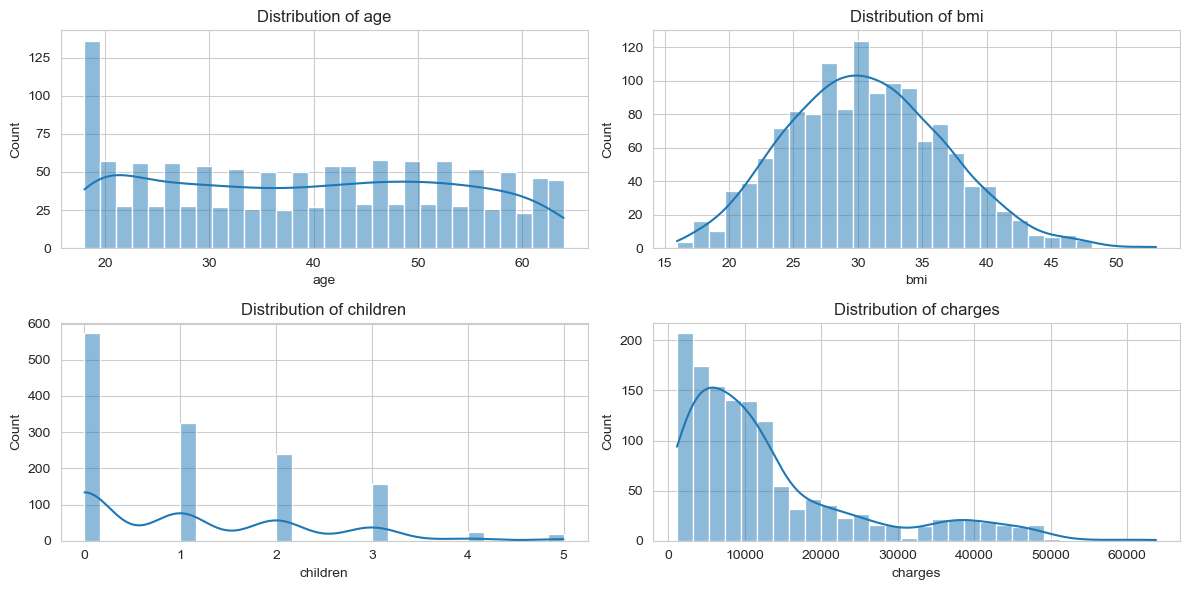

In [33]:
# Plot histograms with kernel density estimates (KDE) to visualize the distribution of numerical columns
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Insight:**
- age is roughly uniformly distributed (range 18-64).

- bmi is about normal, centred around 30.

- children is skewed towards 0-3 children, with few having 5-6.

- charges is strongly right skewed - most charges are low, but a long tail of very high charges exists.

#### Categorical Variables

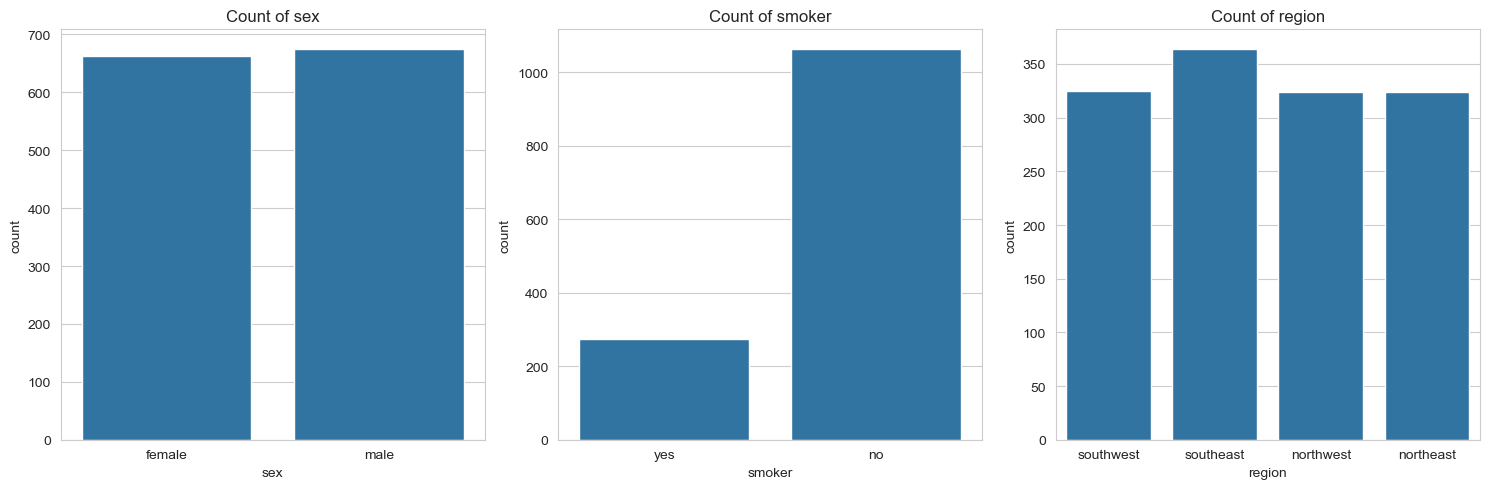

In [30]:
# Plot count of each category for all categorical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
plt.tight_layout()
plt.show()

**Insight:**

- Slightly more males than females.

- About 1/4 of individuals are smokers.

- Region distribution is fairly balanced.

## Bivariate Analysis

Explore relationships between two variables, focusing on how they affect insurance charges.

#### Charges vs Age

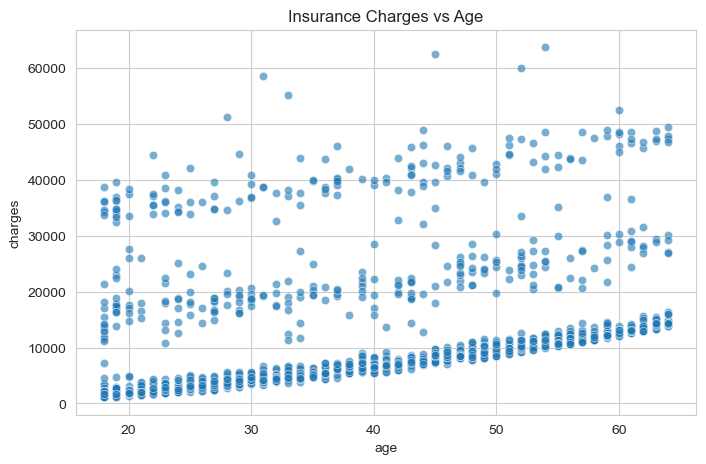

In [34]:
# Scatter plot to visualize the relationship between age and insurance charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.6)
plt.title('Insurance Charges vs Age')
plt.show()


**Insight:** Charges generally increase with age, but there is a lot of variation. There is a cluster of very high charges at all ages - my assumption is that these are likely smokers.

#### Charges vs BMI

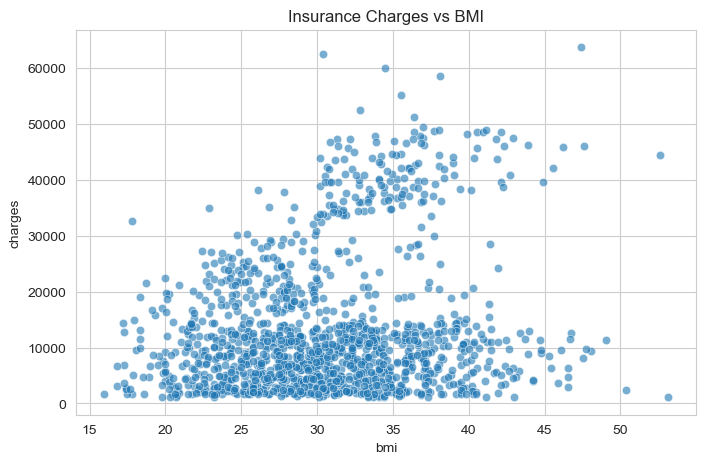

In [46]:
# Scatter plot to examine the relationship between BMI and insurance charges
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.6)
plt.title('Insurance Charges vs BMI')
plt.show()

**Insight:** No strong linear relationship, but the highest charges appear at moderate BMI values (around 30-40). My assumption is that these separation might be due to smoking status.

#### Charges vs Children

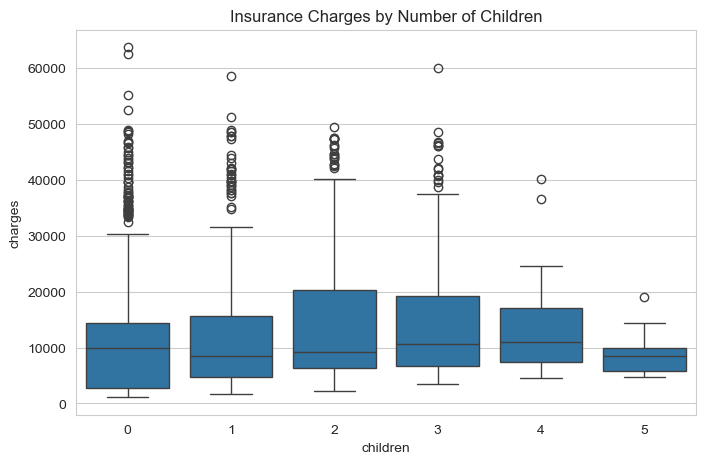

In [47]:
# Box plot to compare the distribution of insurance charges across different numbers of children
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='children', y='charges')
plt.title('Insurance Charges by Number of Children')
plt.show()

**Insight:** Median charges are similar across children count, though the spread is larger for 0-2 children. Having many children (4-5) does not consistently increase charges.

#### Charges vs Smoker

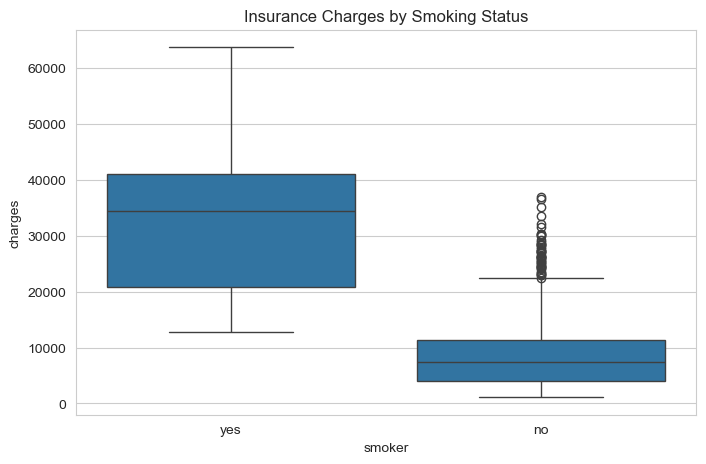

In [53]:
# Box plot to compare insurance charges between smokers and non-smokers
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Insurance Charges by Smoking Status')
plt.show()

**Insight:**  Smokers pay drastically higher charges (median about 34,000) compared to non‑smokers (median about 7,000). This is the strongest single factor.

#### Charges vs Sex

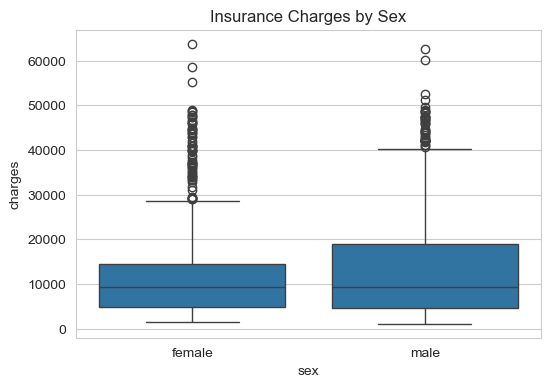

In [50]:
# Box plot to compare the distribution of insurance charges between male and female
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Insurance Charges by Sex')
plt.show()

**Insight:** There is little difference in charges between males and females.

#### Charges vs Region

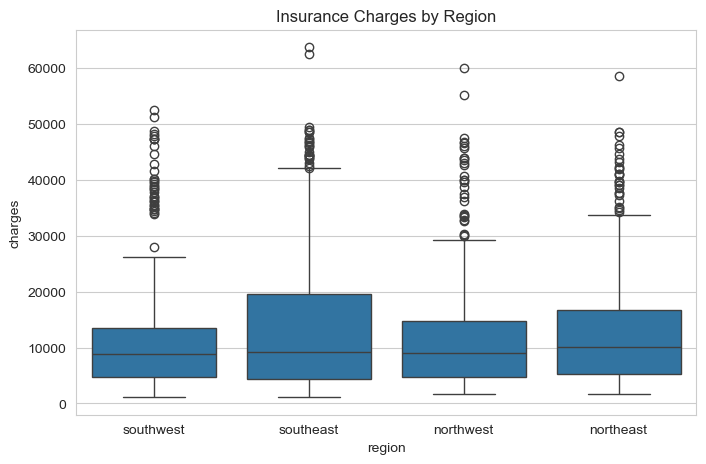

In [49]:
# Box plot to compare the distribution of insurance charges across different regions
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Insurance Charges by Region')
plt.show()

**Insight:** Charges are fairly similar across regions, with southeast slightly higher on average but not statistically significant.

#### Correlation Matrix

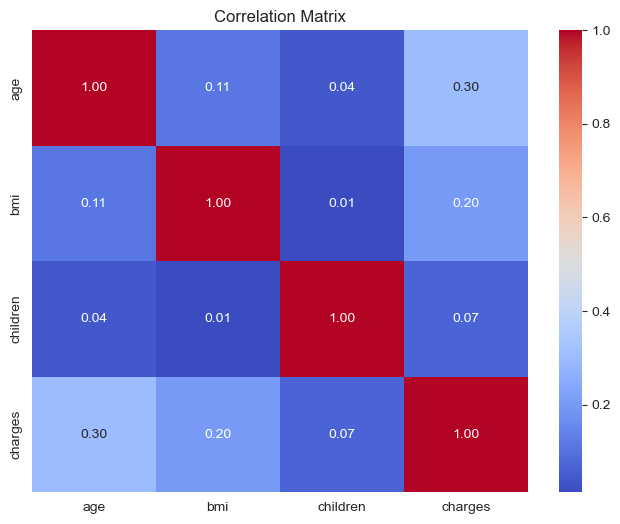

In [48]:
# Compute correlation matrix for numerical features and visualize as a heatmap
corr = df[['age', 'bmi', 'children', 'charges', ]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Insight:** Age has a weak positive correlation with charges (0.30). BMI and children have very weak correlations. This suggests that charges are not linearly related to these variables alone; smoking likely interacts with them.

### Multivariate Analysis

Examine how multiple variables interact to influence charges.

#### Pairplot with Colour by Smoker

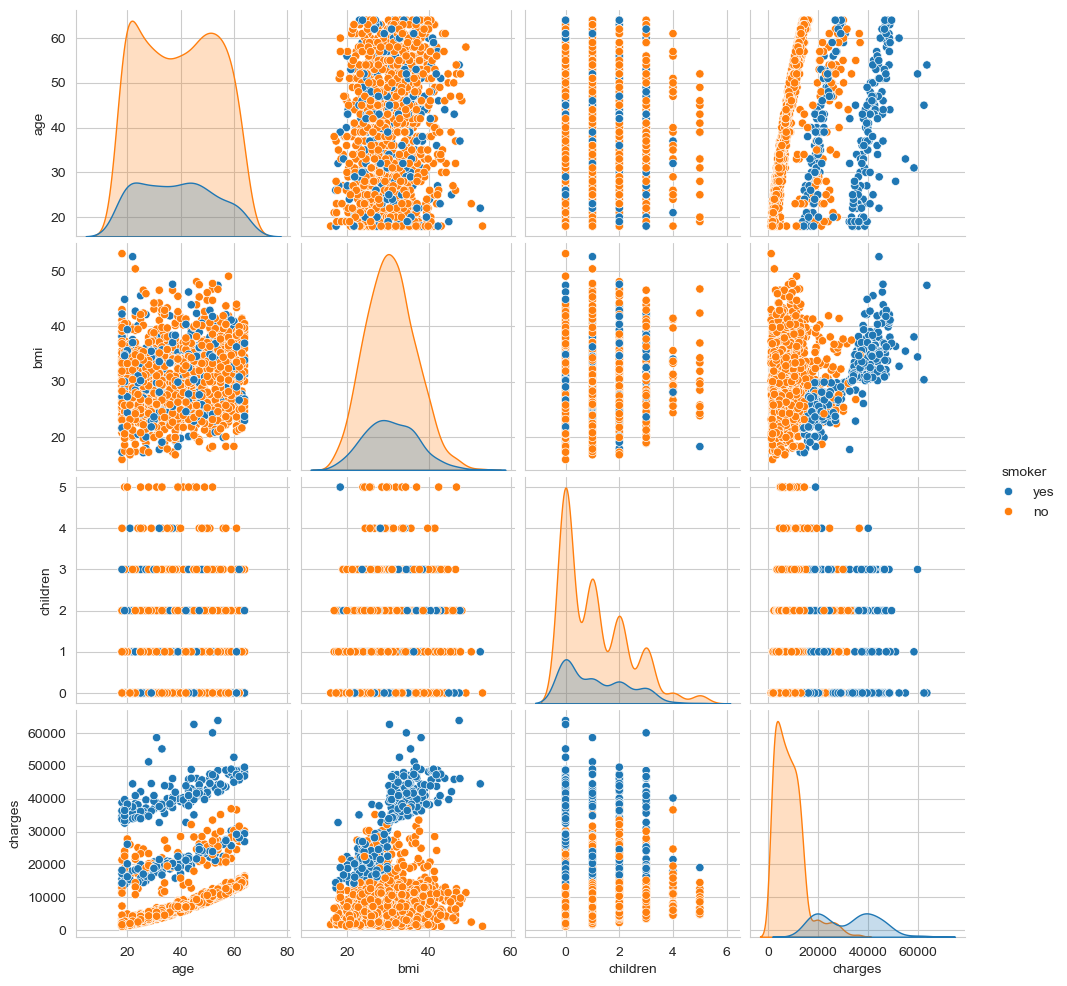

In [13]:
# Pairplot to visualize the relationships between numerical features
sns.pairplot(df, vars=['age', 'bmi', 'children', 'charges'], hue='smoker')
plt.show()

**Insight:** The scatter plots show a clear separation between smokers (blue) and non‑smokers (orange). For smokers, charges increase with age and BMI; for non‑smokers, charges remain relatively low regardless of age and BMI.

#### Charges vs sex and Smoker

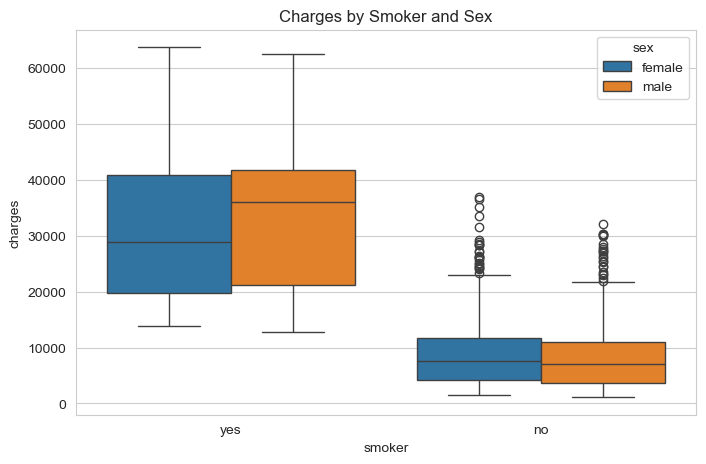

In [5]:
# Box plot comparing insurance charges by smoking status and gender
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='smoker', y='charges', hue='sex')
plt.title('Charges by Smoker and Sex')
plt.show()

**Insight:** Both male and female smokers have similar high charges; non‑smokers have low charges regardless of sex.

#### Charges vs Age and BMI, Faceted by Smoker

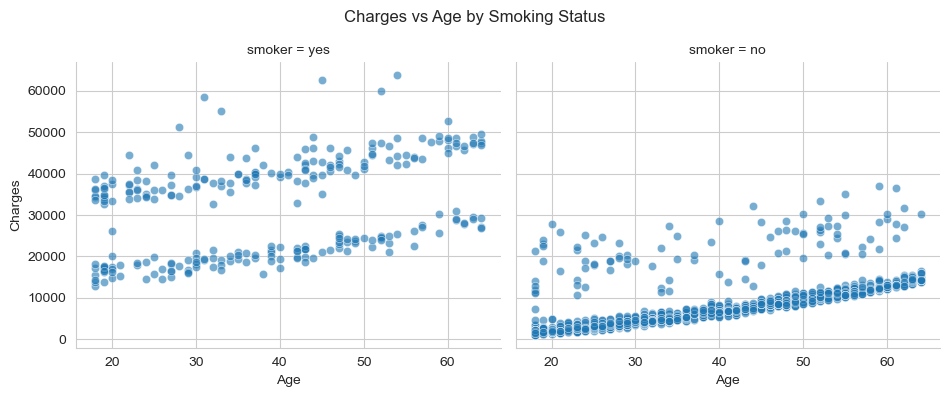

In [8]:
# Faceted scatter plots to examine age vs charges relationship separately for smokers and non-smokers
g = sns.FacetGrid(df, col='smoker', height=4, aspect=1.2)
g.map(sns.scatterplot, 'age', 'charges', alpha=0.6)
g.set_axis_labels('Age', 'Charges')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Charges vs Age by Smoking Status')
plt.show()

**Insight:** Among smokers, charges increase with age; among non‑smokers, charges are consistently low across all ages.

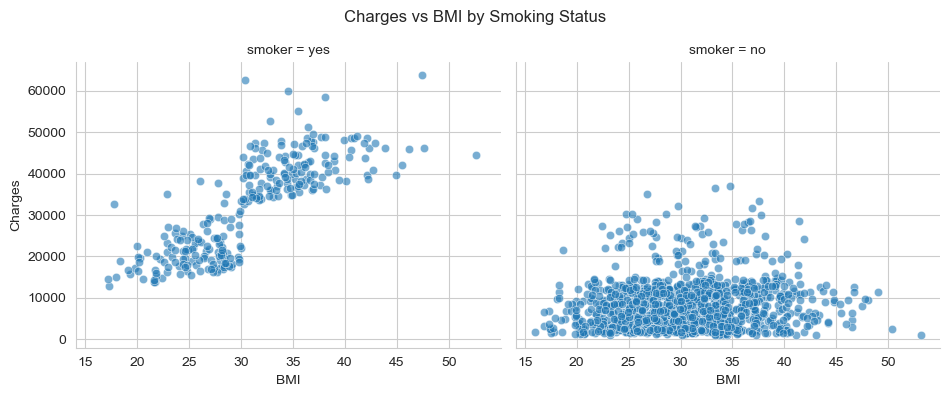

In [9]:
# Faceted scatter plots showing BMI vs charges relationship, separated by smoking status
g = sns.FacetGrid(df, col='smoker', height=4, aspect=1.2)
g.map(sns.scatterplot, 'bmi', 'charges', alpha=0.6)
g.set_axis_labels('BMI', 'Charges')
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Charges vs BMI by Smoking Status')
plt.show()

**Insight:** For smokers, higher BMI tends to lead to higher charges; for non‑smokers, BMI has little effect.

#### Average Charges by Age Group and Smoker

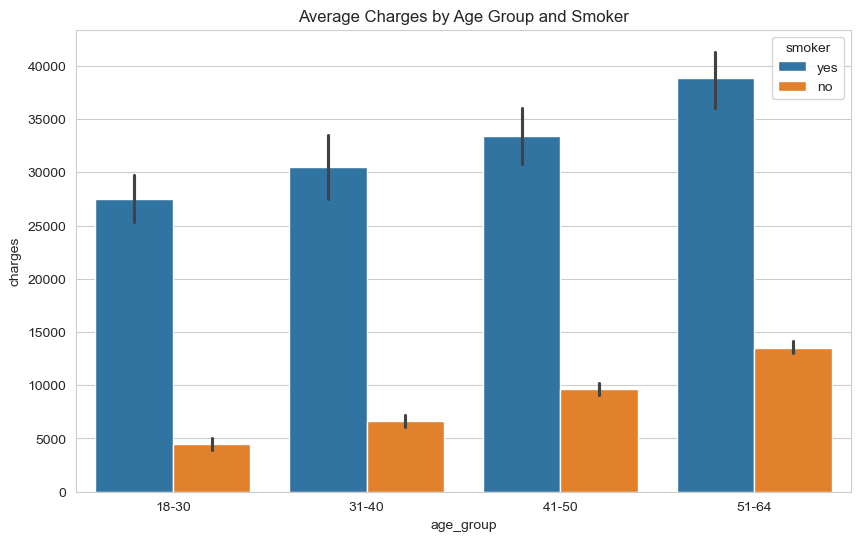

In [13]:
# Create age groups and visualize average charges by age group and smoking status
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 65], labels=['18-30', '31-40', '41-50', '51-64'])
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='age_group', y='charges', hue='smoker')
plt.title('Average Charges by Age Group and Smoker')
plt.show()

**Insight:** Smokers in all age groups pay much more, and charges increase with age for both groups, but the increase is steeper for smokers.

#### Outlier Detection

In [37]:
# Detect outliers in charges using the Interquartile Range (IQR) method

# Calculate quartiles
Q1 = df['charges'].quantile(0.25)  # First quartile (25th percentile)
Q3 = df['charges'].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile range

# Define outlier boundaries
lower = Q1 - 1.5 * IQR  # Lower bound (values below this are outliers)
upper = Q3 + 1.5 * IQR  # Upper bound (values above this are outliers)

# Identify outliers
outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]

# Display outlier statistics
print(f"Number of outliers in charges: {len(outliers)}")
print("Percentage of outliers: {:.2f}%".format(len(outliers)/len(df)*100))

Number of outliers in charges: 139
Percentage of outliers: 10.39%


Many of these outliers are actually smokers with high charges - they are valid extreme values rather than data errors.

##  Data preparation

#### Convert Categories to Numbers

In [4]:
# Create dummy variables for categorical columns
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Check the resulting dataframe
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


#### Define Features (X) and Target (y)

In [22]:
# Separate features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

**Insight:**
- X = all columns except charges (age, bmi, children, sex_male, smoker_yes, and three region columns).
- y = the target we want to predict - insurance charges.

## Feature Selection

In [23]:
# Pick the 5 most important features using a statistical test (F-test)
selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(X, y)

# Show which features were chosen
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print("Selected features:", list(selected_features))



Selected features: ['age', 'bmi', 'children', 'smoker_yes', 'region_southeast']


**Insight:**
5 of the most useful for predicting charges:

- age, bmi, number of children, smoker_yes, and region_southeast.

- The  sex and the other two regions were dropped because they do not add much predictive power.


**Feature selection for South Africa:**
- region_southeast  was selected as important in the US dataset.
- In a South African model, we would one-hot encode provinces.
- The same statistical test (f_regression) would identify which provinces matter most for pricing.

## Separate Train  and  Test 

In [25]:
# Split the data 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

**Insight** 
- 80% of the data is used for training, 20% for testing.
- The random_state=42 makes sure the split is the same every time you run the code.

## First Linear Regression Model

In [27]:
# Train a simple linear regression model and use it to predict outcomes for both training and test data
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Model Performance Metrics

**matrix we are judging on:**
- R² says how much variance explained which is good for comparing models.

- MAE & RMSE satates how much money we might be wrong by which is good for business decisions.

- Comparing Train vs Test R²  shows if the model is overfitting or not, great to get reliablity of model.

In [29]:
# Evaluate the model performance
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n- Initial Model (Linear with selected features) -")
print(f"Train R²: {train_r2:.3f}")   
print(f"Test R²:  {test_r2:.3f}")    
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")


- Initial Model (Linear with selected features) -
Train R²: 0.741
Test R²:  0.782
Mean Absolute Error: $4200.49
Root Mean Squared Error: $5815.52


 **Insights:** 

R² on test set = 0.782 - Meaning the model explains about 78% of the variation in charges.

Train R² (0.741) vs Test R² (0.782) - They are very close. No overfitting meaing the model is not memorising the training data.

MAE -  On average, the prediction is off by about $4,200.

RMSE - Larger errors (outliers) have a bigger penalty. The difference between MAE and RMSE suggests some predictions are far from the true values.

## Checking Model Assumptions

#### Residual Plot (Test Set)

Text(0.5, 1.0, 'Residual Plot (Test Set)')

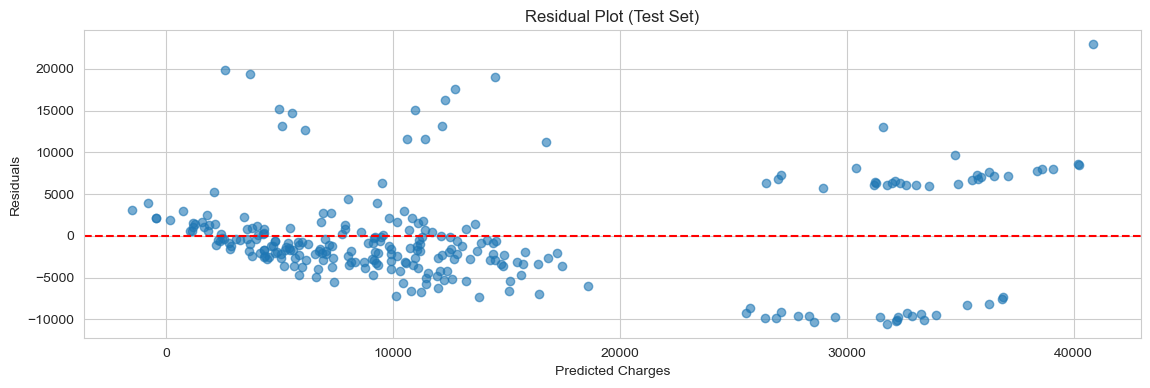

In [38]:
# Calculate (residuals) and plot them against predicted values to check for patterns
residuals = y_test - y_test_pred
plt.figure(figsize=(30, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot (Test Set)')



**Insight:**
- Here we see heteroscedasticity - the spread of residuals grows for higher predicted charges.
- This violates one assumption of linear regression (constant variance). It means the model struggles to predict high charges accurately.

#### Q‑Q Plot of Residuals

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

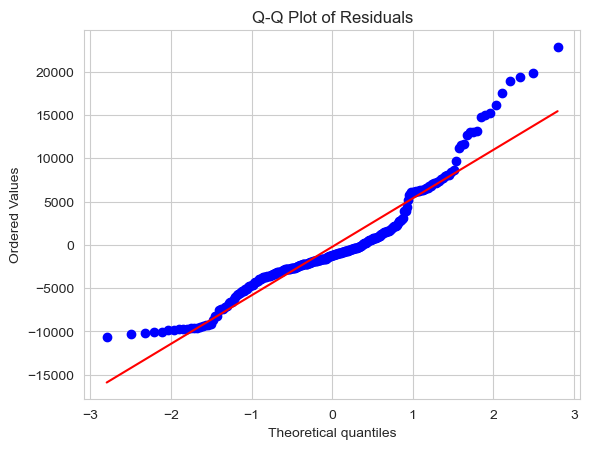

In [17]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

## Improved Model: Polynomial Features (Degree 2)

In [39]:
# Create polynomial features (degree 2) 
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a new linear regression model using polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Make predictions on both training and test sets
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)

# Evaluate the polynomial model 
train_r2_poly = r2_score(y_train, y_train_pred_poly)
test_r2_poly = r2_score(y_test, y_test_pred_poly)
mae_poly = mean_absolute_error(y_test, y_test_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

# Print results
print("\n- Retrained Model (Polynomial Features, degree=2) -")
print(f"Train R²: {train_r2_poly:.3f}")   
print(f"Test R²:  {test_r2_poly:.3f}")    
print(f"Mean Absolute Error: ${mae_poly:.2f}")
print(f"Root Mean Squared Error: ${rmse_poly:.2f}")


- Retrained Model (Polynomial Features, degree=2) -
Train R²: 0.837
Test R²:  0.870
Mean Absolute Error: $2733.41
Root Mean Squared Error: $4497.11


**Insights:**

- Test R² jumped from 0.782  to  0.870 - The polynomial model explains 87% of the variation, a big improvement.

- MAE dropped from 4200 to 2733 - Average error is now $1,500 smaller.

- RMSE dropped from 5815 to  4497 - Large errors are also much smaller.

- Train R² (0.837) vs Test R² (0.870) – still no overfitting.

- This shows that non‑linear relationships like age² or bmi × smoker are important for predicting insurance charges.

#### Conclusion & South African Deployment Readiness

The polynomial regression model (degree 2) achieves **87% explained variance** on US data.  
It successfully handles non-linear relationships (age², smoker × BMI).

**To deploy in South Africa:**  
- No algorithm change - just swap region categories.  
- The scheme must collect **province** for each member.  
- Retrain with the same PolynomialFeatures pipeline.  
- Monitor for new factors ( urban vs rural, access to public hospitals).

This notebook serves as a **validated blueprint** for the South African medical aid scheme.